<a href="https://colab.research.google.com/github/austinmallie/ADS599_Capstone/blob/main/EDA/Breach_EDA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Import Data & Libraries


In [48]:
from google.colab import userdata
import os

token = userdata.get('Github')
owner = "austinmallie"
repo = "ADS599_Capstone"
repo_url = f"https://{token}@github.com/{owner}/{repo}.git"

# Only clone if the folder doesn't exist already
if not os.path.exists(repo):
    !git clone {repo_url}
else:
    print("Repo already cloned. Pulling latest changes...")
    %cd {repo}
    !git pull

%cd /content/{repo}

Cloning into 'ADS599_Capstone'...
remote: Enumerating objects: 156, done.
remote: Counting objects: 100% (156/156), done.
remote: Compressing objects: 100% (150/150), done.
remote: Total 156 (delta 40), reused 0 (delta 0), pack-reused 0 (from 0)
Receiving objects: 100% (156/156), 23.22 MiB | 7.84 MiB/s, done.
Resolving deltas: 100% (40/40), done.
/content/ADS599_Capstone


In [3]:
# Create the EDA directory if it doesn't exist
folder_name = "EDA"
if not os.path.exists(folder_name):
    os.makedirs(folder_name)

In [5]:
target_file_path = 'Data-Folder/Breach-Data/Completed_breach_report.csv'

if os.path.isdir(folder_name):
    print(f"✅ Confirmation: '{folder_name}' folder exists.")

    # Check for the file in the subfolder
    if os.path.exists(target_file_path):
        print(f"✅ Data File Found: '{target_file_path}' is ready for analysis.")
    else:
        print(f"❌ Error: File NOT found at {target_file_path}.")
        # Debug: Let's see what is inside the Breach-Data folder
        if os.path.exists('Data-Folder/Breach-Data'):
            print("Contents of Breach-Data folder:", os.listdir('Data-Folder/Breach-Data'))
else:
    print(f"❌ Error: '{folder_name}' was not found.")

✅ Confirmation: 'EDA' folder exists.
✅ Data File Found: 'Data-Folder/Breach-Data/Completed_breach_report.csv' is ready for analysis.


In [6]:
#library imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [7]:
#import data
df = pd.read_csv("Data-Folder/Breach-Data/Completed_breach_report.csv")
df.head()

,javax.faces.component.UIPanel@5517616a,State,Covered Entity Type,Individuals Affected,Breach Submission Date,Type of Breach,Location of Breached Information,javax.faces.component.UIPanel@55f85fe,Web Description
0,La Pine Community Health Center,OR,Healthcare Provider,1190.0,02/05/2026,Hacking/IT Incident,Desktop Computer,Yes,"The covered entity (CE), La Pine Community Hea..."
1,Ko-Kwel Wellness Center,OR,Healthcare Provider,543.0,02/03/2026,Hacking/IT Incident,Network Server,Yes,"The covered entity (CE), Ko-Kwel Wellness Cent..."
2,LifeLong Medical Care,CA,Healthcare Provider,70000.0,01/30/2026,Unauthorized Access/Disclosure,Other,Yes,"The covered entity (CE), LifeLong Medical Care..."
3,Chattanooga C.A.R.E.S. d/b/a Cempa Community Care,TN,Healthcare Provider,1341.0,01/30/2026,Unauthorized Access/Disclosure,Other,Yes,"The covered entity (CE), Chattanooga C.A.R.E.S..."
4,Axis Healthcare Group P.C.,MD,Healthcare Provider,3537.0,01/28/2026,Hacking/IT Incident,Email,No,"Axis Healthcare Group P.C., the covered entity..."


# Basic Data Information

In [8]:
#get shape
df.shape

(6703, 9)

In [9]:
#are there duplicates?
df.duplicated().sum()

np.int64(0)

In [10]:
#get datatypes
df.dtypes

,0
javax.faces.component.UIPanel@5517616a,object
State,object
Covered Entity Type,object
Individuals Affected,float64
Breach Submission Date,object
Type of Breach,object
Location of Breached Information,object
javax.faces.component.UIPanel@55f85fe,object
Web Description,object


# Data Preprocessing & Target Alignment

In [11]:
# Column Renaming (Fixing the headers)
df = df.rename(columns={
    'javax.faces.component.UIPanel@5517616a': 'Entity_Name',
    'javax.faces.component.UIPanel@55f85fe': 'Business_Associate_Involved',
    'State': 'State', # Already clean
    'Covered Entity Type': 'Entity_Type',
    'Individuals Affected': 'Individuals_Affected',
    'Breach Submission Date': 'Breach_Date',
    'Type of Breach': 'Type_of_Breach',
    'Location of Breached Information': 'Breach_Location',
    'Web Description': 'Web_Description'
})

In [12]:
# Date Standardization
df['Breach_Date'] = pd.to_datetime(df['Breach_Date'], errors='coerce')

## Review Missing Values

In [13]:
# Check for Nulls
print("--- MISSING DATA CHECK ---")
print(df.isnull().sum())

--- MISSING DATA CHECK ---
Entity_Name                      0
State                           20
Entity_Type                      5
Individuals_Affected             1
Breach_Date                      0
Type_of_Breach                   1
Breach_Location                  0
Business_Associate_Involved      0
Web_Description                200
dtype: int64


In [14]:
# Isolate the row with the missing value to show the 'Consolidated' note
missing_row = df[df['Individuals_Affected'].isnull()]

print("--- INVESTIGATING MISSING DATA ---")
print("Targeting the row where 'Individuals_Affected' is null:")
display(missing_row[['Entity_Name', 'Individuals_Affected', 'Web_Description']])

--- INVESTIGATING MISSING DATA ---
Targeting the row where 'Individuals_Affected' is null:


,Entity_Name,Individuals_Affected,Web_Description
5902,Valperaiso Fire Department,NaN,This case has been consolidated with another r...


In [21]:
# Dropping rows where 'Individuals_Affected' is NaN since the one we found is a consolidated duplicate anyway
df = df.dropna(subset=['Individuals_Affected'])

In [22]:
# Search for 'consolidated' in the Web_Description column
# We use case=False so it finds 'Consolidated', 'consolidated', or 'CONSOLIDATED'
consolidated_rows = df[df['Web_Description'].str.contains('consolidated', case=False, na=False)]

print(f"--- AUDIT: FOUND {len(consolidated_rows)} CONSOLIDATED RECORDS ---")

--- AUDIT: FOUND 81 CONSOLIDATED RECORDS ---


In [23]:
# Display the relevant columns to see if they are duplicates or missing data
display(consolidated_rows[['Entity_Name', 'Entity_Type', 'Web_Description']])

,Entity_Name,Entity_Type,Web_Description
160,Vision Upright MRI,Healthcare Provider,Vision Upright MRI (CE) reported that it had e...
268,"Rumpke Consolidated Companies, Inc. & Affiliat...",Health Plan,Rumpke Consolidated Companies & Affiliated Ben...
870,Leggett & Platt Incorporated Employee Benefit ...,Health Plan,"The covered entity (CE), Leggett & Platt Incor..."
1310,"Sesame, Inc.",Business Associate,"The business associate (BA), Sesame, Inc., rep..."
1692,Advocate Aurora Health,Healthcare Provider,"The covered entity (CE), Advocate Aurora Healt..."
...,...,...,...
6111,Miami Beach Healthcare Group Ltd. dba Aventura...,Healthcare Provider,This case has been consolidated with another r...
6114,Henry Ford Health System,Healthcare Provider,"Henry Ford Health System, the covered entity (..."
6383,Memorial Health Systems,Healthcare Provider,"On July 12, 2011, the covered entity (CE), Mem..."
6458,Henry Ford Hospital,Healthcare Provider,"The Henry Ford Health System, the covered enti..."


**************WILL REVIEW WITH TEAM HOW TO BEST DEAL WITH THESE CONSOLIDATED REPORTS

In [24]:
# Fill State and Entity Type with 'Unknown'
df['State'] = df['State'].fillna('Unknown')
df['Entity_Type'] = df['Entity_Type'].fillna('Unknown')

# Fill the single missing Breach Type with 'Other'
df['Type_of_Breach'] = df['Type_of_Breach'].fillna('Other')

# Fill Web Description so the Null count goes to zero
df['Web_Description'] = df['Web_Description'].fillna('No description provided')

# Final Verification
print("--- FINAL MISSING DATA CHECK ---")
print(df.isnull().sum())

# Show a few 'Unknown' states to confirm it worked
display(df[df['State'] == 'Unknown'].head(3))

--- FINAL MISSING DATA CHECK ---
Entity_Name                    0
State                          0
Entity_Type                    0
Individuals_Affected           0
Breach_Date                    0
Type_of_Breach                 0
Breach_Location                0
Business_Associate_Involved    0
Web_Description                0
dtype: int64


,Entity_Name,State,Entity_Type,Individuals_Affected,Breach_Date,Type_of_Breach,Breach_Location,Business_Associate_Involved,Web_Description
369,La Liga Puertorriquena Contra El Cancer DBA Ho...,Unknown,Healthcare Provider,4590.0,2024-09-16,Hacking/IT Incident,Email,No,"The covered entity (CE), La Liga Puertorriquen..."
376,Oficina Medica,Unknown,Healthcare Provider,2618.0,2024-09-08,Theft,"Desktop Computer, Other Portable Electronic De...",No,"The covered entity (CE), Oficina Medica, repor..."
379,Guam Seventh-Day Adventist Clinic,Unknown,Healthcare Provider,56635.0,2024-09-06,Hacking/IT Incident,Email,No,"Guam Seventh-Day Adventist Clinic, the covered..."


## Clean up Type_of_Breach

In [35]:
# Review breaches by Type
# Calculate the frequency of each breach type
type_counts = df['Type_of_Breach'].value_counts()

# Print the exact numbers for your report
print("--- BREACH TYPE FREQUENCY ---")
print(type_counts)

--- BREACH TYPE FREQUENCY ---
Type_of_Breach
Hacking/IT Incident                                                                                    3703
Unauthorized Access/Disclosure                                                                         1502
Theft                                                                                                   996
Loss                                                                                                    215
Improper Disposal                                                                                       114
Other                                                                                                    76
Theft, Unauthorized Access/Disclosure                                                                    25
Loss, Theft                                                                                              15
Unknown                                                                                    

In [37]:
# Some lines have multiple selections for breach type
# "Hacking" is considered a higher-tier threat than "Theft," so we'll create a script that looks at the string and assigns a single, primary category based on a hierarchy

def simplify_breach(type_str):
    """
    Groups messy multi-label breach types into 5 clean,
    mutually exclusive categories based on priority.
    """
    type_str = str(type_str)
    # Hacking is the highest priority for our project
    if 'Hacking' in type_str:
        return 'Hacking/IT Incident'
    elif 'Theft' in type_str:
        return 'Theft'
    elif 'Unauthorized Access' in type_str:
        return 'Unauthorized Access/Disclosure'
    elif 'Loss' in type_str:
        return 'Loss'
    elif 'Improper Disposal' in type_str:
        return 'Improper Disposal'
    else:
        return 'Other/Unknown'

# Create the clean column for analysis and modeling
df['Main_Breach_Type'] = df['Type_of_Breach'].apply(simplify_breach)

print("Breach types consolidated into 5 clean categories.")
print(df['Main_Breach_Type'].value_counts())

Breach types consolidated into 5 clean categories.
Main_Breach_Type
Hacking/IT Incident               3718
Unauthorized Access/Disclosure    1513
Theft                             1048
Loss                               221
Improper Disposal                  114
Other/Unknown                       88
Name: count, dtype: int64


## Sort Chronologically

In [38]:
# Sort and Re-index
df = df.sort_values(by='Breach_Date').reset_index(drop=True)

print("✅ Data is now in chronological order.")
print(f"Oldest Breach: {df['Breach_Date'].min()}")
print(f"Newest Breach: {df['Breach_Date'].max()}")

# Preview the most recent breaches
display(df.tail())

✅ Data is now in chronological order.
Oldest Breach: 2009-10-21 00:00:00
Newest Breach: 2026-02-05 00:00:00


,Entity_Name,State,Entity_Type,Individuals_Affected,Breach_Date,Type_of_Breach,Breach_Location,Business_Associate_Involved,Web_Description,Days_Between,Breach_Year,Main_Breach_Type
6697,Axis Healthcare Group P.C.,MD,Healthcare Provider,3537.0,2026-01-28,Hacking/IT Incident,Email,No,"Axis Healthcare Group P.C., the covered entity...",0.0,2026,Hacking/IT Incident
6698,Chattanooga C.A.R.E.S. d/b/a Cempa Community Care,TN,Healthcare Provider,1341.0,2026-01-30,Unauthorized Access/Disclosure,Other,Yes,"The covered entity (CE), Chattanooga C.A.R.E.S...",2.0,2026,Unauthorized Access/Disclosure
6699,LifeLong Medical Care,CA,Healthcare Provider,70000.0,2026-01-30,Unauthorized Access/Disclosure,Other,Yes,"The covered entity (CE), LifeLong Medical Care...",0.0,2026,Unauthorized Access/Disclosure
6700,Ko-Kwel Wellness Center,OR,Healthcare Provider,543.0,2026-02-03,Hacking/IT Incident,Network Server,Yes,"The covered entity (CE), Ko-Kwel Wellness Cent...",4.0,2026,Hacking/IT Incident
6701,La Pine Community Health Center,OR,Healthcare Provider,1190.0,2026-02-05,Hacking/IT Incident,Desktop Computer,Yes,"The covered entity (CE), La Pine Community Hea...",2.0,2026,Hacking/IT Incident


# Visualizations

## Review Breaches

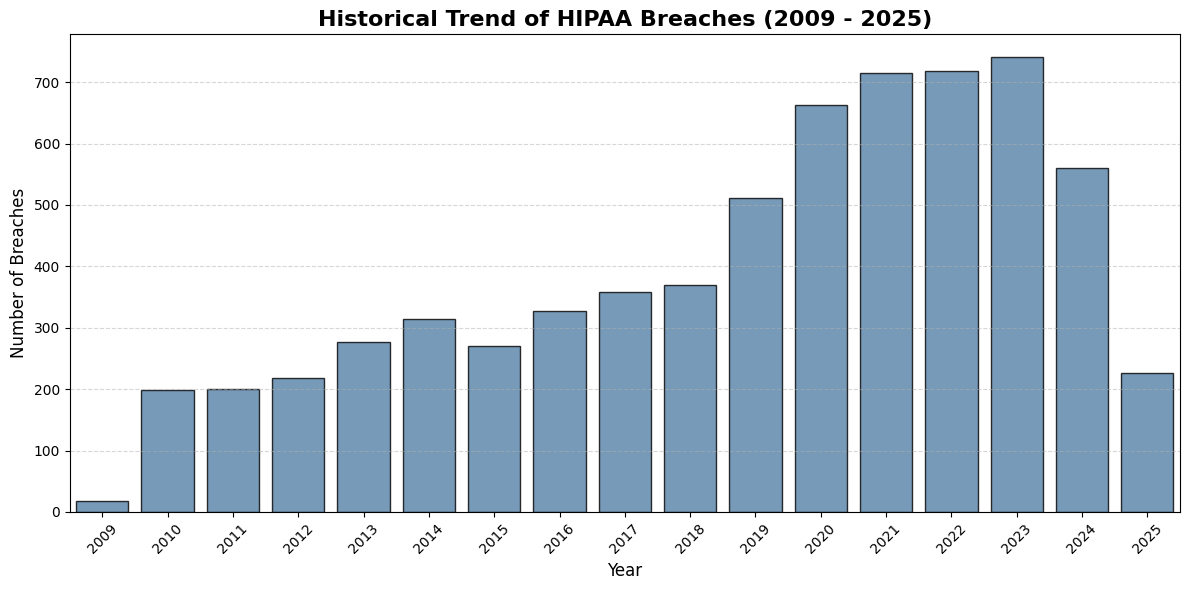

In [39]:
import matplotlib.pyplot as plt
import seaborn as sns

# Create a "Year" column to make grouping easier
df['Breach_Year'] = df['Breach_Date'].dt.year

# Count Breaches by Year to see the 'Trend'
breach_trends = df.groupby('Breach_Year').size()

# Filter out 2026 to avoid showing a "drop" due to incomplete data
plot_data = breach_trends[breach_trends.index < 2026]

plt.figure(figsize=(12, 6))
sns.barplot(x=plot_data.index, y=plot_data.values, color='steelblue', edgecolor='black', alpha=0.8)

plt.title('Historical Trend of HIPAA Breaches (2009 - 2025)', fontsize=16, fontweight='bold')
plt.xlabel('Year', fontsize=12)
plt.ylabel('Number of Breaches', fontsize=12)
plt.xticks(rotation=45)

# Adding a clean horizontal grid for readability
plt.grid(axis='y', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

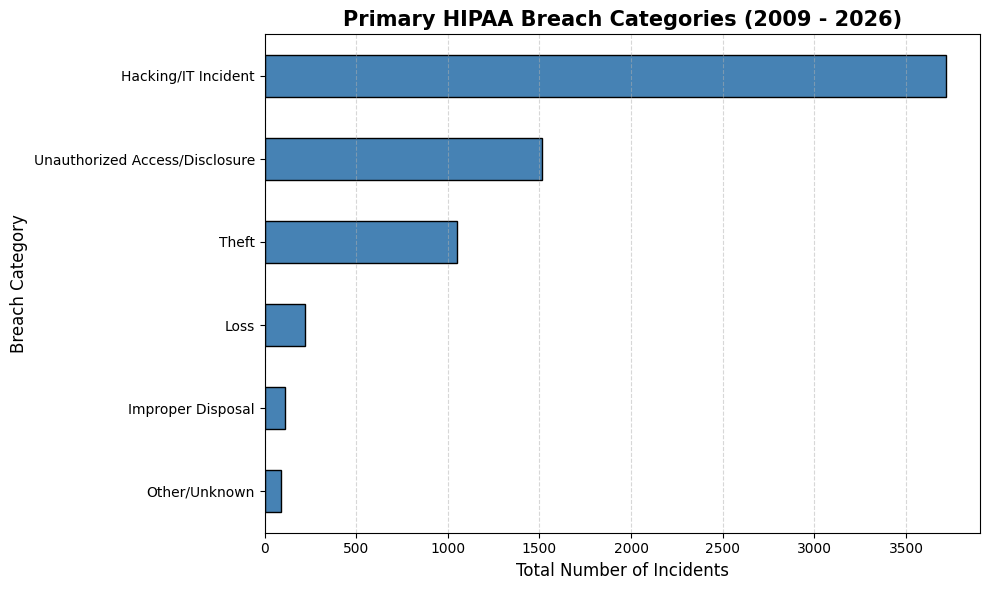

--- CLEANED BREACH CATEGORIES ---
Main_Breach_Type
Hacking/IT Incident               3718
Unauthorized Access/Disclosure    1513
Theft                             1048
Loss                               221
Improper Disposal                  114
Other/Unknown                       88
Name: count, dtype: int64


In [41]:
# Calculate the frequency of the Cleaned breach typw categories
main_type_counts = df['Main_Breach_Type'].value_counts()
plt.figure(figsize=(10, 6))
main_type_counts.plot(kind='barh', color='steelblue', edgecolor='black')
plt.title('Primary HIPAA Breach Categories (2009 - 2026)', fontsize=15, fontweight='bold')
plt.xlabel('Total Number of Incidents', fontsize=12)
plt.ylabel('Breach Category', fontsize=12)
plt.grid(axis='x', linestyle='--', alpha=0.5)

# Invert y-axis so 'Hacking' (the most frequent) is at the top
plt.gca().invert_yaxis()

plt.tight_layout()
plt.show()

print("--- CLEANED BREACH CATEGORIES ---")
print(main_type_counts)

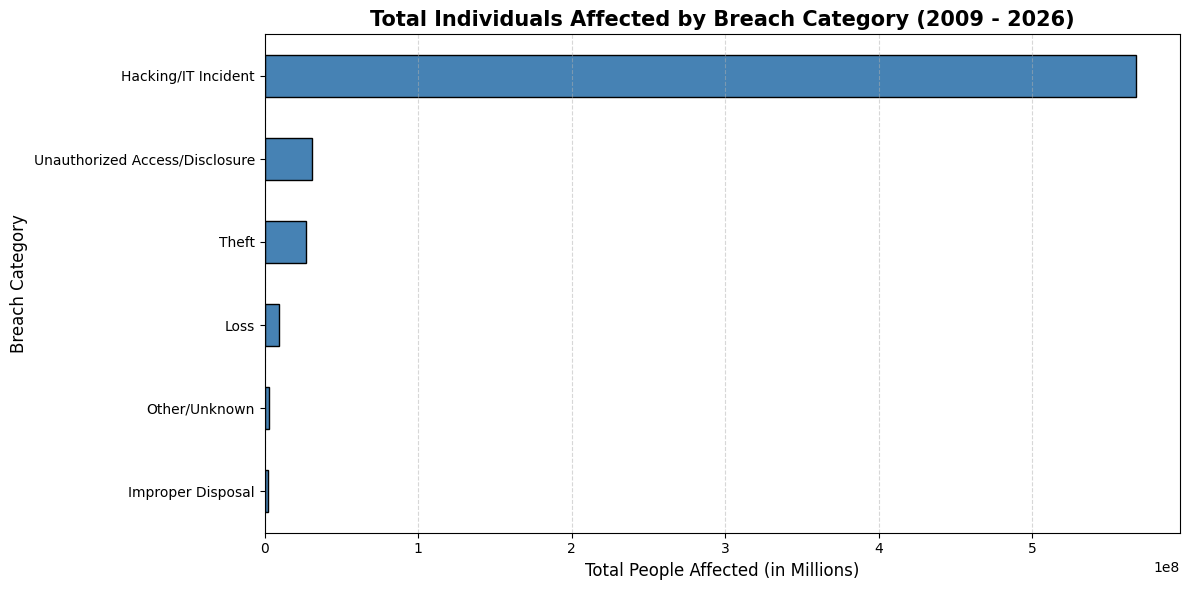

--- SEVERITY STATS BY TYPE ---
                                Total_Millions  median
Main_Breach_Type                                      
Hacking/IT Incident                     567.77  8173.5
Unauthorized Access/Disclosure           31.17  1700.0
Theft                                    27.15  2177.0
Loss                                      9.45  1900.0
Other/Unknown                             3.16  1800.0
Improper Disposal                         2.09  1879.5


In [43]:
# Visualize Individuals Affected
# Calculate Total Impact (Sum) and Typical Severity (Median)
impact_stats = df.groupby('Main_Breach_Type')['Individuals_Affected'].agg(['sum', 'median']).sort_values(by='sum', ascending=False)

# Visualize Total Impact
plt.figure(figsize=(12, 6))
impact_stats['sum'].plot(kind='barh', color='steelblue', edgecolor='black')

# Formatting for large numbers (Millions)
plt.title('Total Individuals Affected by Breach Category (2009 - 2026)', fontsize=15, fontweight='bold')
plt.xlabel('Total People Affected (in Millions)', fontsize=12)
plt.ylabel('Breach Category', fontsize=12)
plt.grid(axis='x', linestyle='--', alpha=0.5)
plt.gca().invert_yaxis()

plt.tight_layout()
plt.show()

# Print the stats
print("--- SEVERITY STATS BY TYPE ---")
# Formatting the sum to be more readable
impact_stats['Total_Millions'] = (impact_stats['sum'] / 1_000_000).round(2)
print(impact_stats[['Total_Millions', 'median']])

In [44]:
# Isolate the top 10 largest breaches
top_10_breaches = df.sort_values(by='Individuals_Affected', ascending=False).head(10)

# Display the key details
print("--- THE 10 LARGEST HIPAA BREACHES IN HISTORY ---")
display(top_10_breaches[['Entity_Name', 'State', 'Breach_Date', 'Individuals_Affected', 'Main_Breach_Type']])

# Review how much these 10 rows contribute to the total
top_10_sum = top_10_breaches['Individuals_Affected'].sum()
total_sum = df['Individuals_Affected'].sum()
percentage = (top_10_sum / total_sum) * 100

print(f"\nThese top 10 breaches alone account for {percentage:.1f}% of all affected individuals.")

--- THE 10 LARGEST HIPAA BREACHES IN HISTORY ---


,Entity_Name,State,Breach_Date,Individuals_Affected,Main_Breach_Type
1252,Anthem Inc.,IN,2015-02-13,78800000.0,Hacking/IT Incident
5762,"Welltok, Inc.",CO,2023-11-06,14782887.0,Hacking/IT Incident
2784,"Optum360, LLC",MN,2019-07-01,11500000.0,Hacking/IT Incident
5575,HCA Healthcare,TN,2023-07-31,11270000.0,Hacking/IT Incident
1275,Premera Blue Cross,WA,2015-03-17,11000000.0,Hacking/IT Incident
2806,Laboratory Corporation of America Holdings dba...,NC,2019-07-13,10251784.0,Hacking/IT Incident
1415,"Excellus Health Plan, Inc.",NY,2015-09-09,9358891.0,Hacking/IT Incident
5750,"Perry Johnson & Associates, Inc. dba PJ&A",NV,2023-11-03,9302588.0,Hacking/IT Incident
5585,"Maximus, Inc.",VA,2023-08-04,9179390.0,Hacking/IT Incident
5434,Managed Care of North America,GA,2023-05-26,8627242.0,Hacking/IT Incident



These top 10 breaches alone account for 27.2% of all affected individuals.


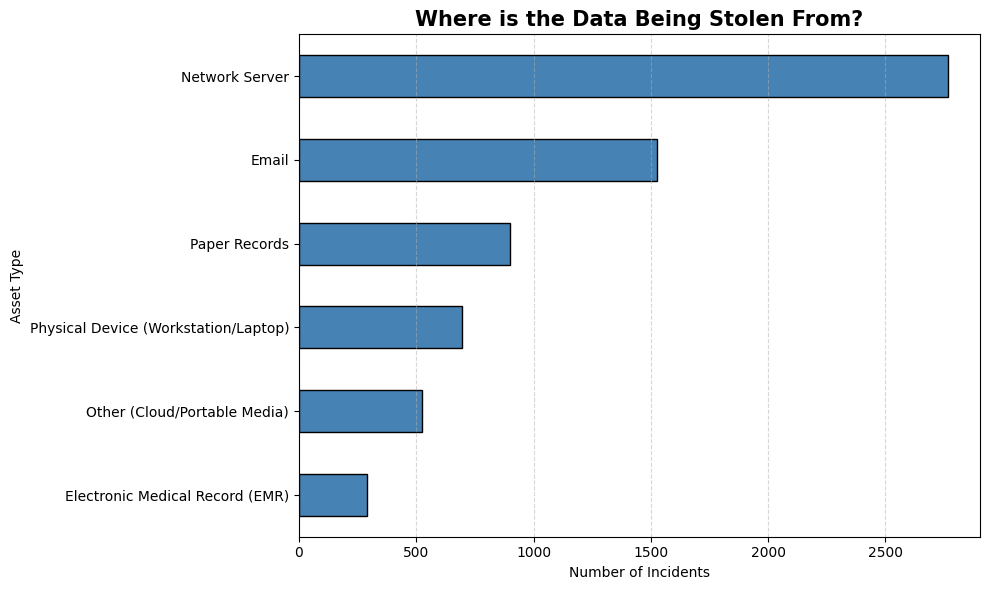

--- TOP DATA LOCATIONS ---
Main_Location
Network Server                          2765
Email                                   1527
Paper Records                            900
Physical Device (Workstation/Laptop)     694
Other (Cloud/Portable Media)             524
Electronic Medical Record (EMR)          292
Name: count, dtype: int64


In [45]:
# Clean up the 'Breach_Location'
def simplify_location(loc_str):
    loc_str = str(loc_str)
    if 'Network Server' in loc_str:
        return 'Network Server'
    elif 'Email' in loc_str:
        return 'Email'
    elif 'Laptop' in loc_str or 'Desktop' in loc_str:
        return 'Physical Device (Workstation/Laptop)'
    elif 'Paper' in loc_str:
        return 'Paper Records'
    elif 'Electronic Medical Record' in loc_str:
        return 'Electronic Medical Record (EMR)'
    else:
        return 'Other (Cloud/Portable Media)'

df['Main_Location'] = df['Breach_Location'].apply(simplify_location)

# Visualize the results
location_counts = df['Main_Location'].value_counts()

plt.figure(figsize=(10, 6))
location_counts.plot(kind='barh', color='steelblue', edgecolor='black')

plt.title('Where is the Data Being Stolen From?', fontsize=15, fontweight='bold')
plt.xlabel('Number of Incidents')
plt.ylabel('Asset Type')
plt.grid(axis='x', linestyle='--', alpha=0.5)
plt.gca().invert_yaxis()

plt.tight_layout()
plt.show()

print("--- TOP DATA LOCATIONS ---")
print(location_counts)

In [49]:
!git config --global user.email "cportalesloebell@sandiego.edu"
!git config --global user.name "Cynthia"

# Add all the new cleaning code and the visualizations I just made
!git add .

# Create a 'message' describing what I did
!git commit -m "Cleaned breach types and locations, added EDA visualizations"

# 3. Push to the 'main' branch
!git push origin main

hint: You've added another git repository inside your current repository.
hint: Clones of the outer repository will not contain the contents of
hint: the embedded repository and will not know how to obtain it.
hint: If you meant to add a submodule, use:
hint: 
hint: 	git submodule add <url> ADS599_Capstone
hint: 
hint: If you added this path by mistake, you can remove it from the
hint: index with:
hint: 
hint: 	git rm --cached ADS599_Capstone
hint: 
hint: See "git help submodule" for more information.
[main 914771d] Cleaned breach types and locations, added EDA visualizations
 2 files changed, 8346 insertions(+)
 create mode 160000 ADS599_Capstone
 create mode 100644 Data-Folder/Breach-Data/Breach_Data_Cleaned.csv
Enumerating objects: 8, done.
Counting objects: 100% (8/8), done.
Delta compression using up to 2 threads
Compressing objects: 100% (5/5), done.
Writing objects: 100% (5/5), 840.33 KiB | 3.91 MiB/s, done.
Total 5 (delta 0), reused 0 (delta 0), pack-reused 0
To https://github.

In [47]:
# Make sure you are in the right directory
%cd /content/ADS599_Capstone/

# Save the current state of your data to a CSV for model use
df.to_csv('Data-Folder/Breach-Data/Breach_Data_Cleaned.csv', index=False)

# Check what Git sees now
!git status

/content/ADS599_Capstone
On branch main
Your branch is up to date with 'origin/main'.

Untracked files:
  (use "git add <file>..." to include in what will be committed)
	Data-Folder/Breach-Data/Breach_Data_Cleaned.csv

nothing added to commit but untracked files present (use "git add" to track)
